# seq2ribo: Predict Ribosome Profiles from RNA Sequence

**seq2ribo** predicts where ribosomes sit on an mRNA transcript using only the RNA sequence as input. It combines a **structure-aware stochastic simulation (sTASEP)** of ribosome traffic with a **neural network polisher (Mamba)** to produce per-codon ribosome occupancy profiles, translation efficiency (TE) estimates, and protein expression predictions.

### Pipeline overview

```
RNA sequence
    │
    ├── ViennaRNA folding → secondary structure → per-codon geometry features
    │
    ├── sTASEP simulation  → physics-based ribosome occupancy estimate
    │
    └── Mamba polisher     → refined per-codon ribosome counts
                                │
                                ├── A-site profile (riboseq task)
                                ├── Translation efficiency (TE task)
                                └── Protein expression (protein task)
```

**Supported cell lines:** HEK293, LCL, RPE-1, iPSC

**Paper:** [bioRxiv](https://www.biorxiv.org/content/10.64898/2026.02.08.700508v2)  
**Repository:** [github.com/Kingsford-Group/seq2ribo](https://github.com/Kingsford-Group/seq2ribo)

---
## 1. Setup

Import the library and initialize the predictor. Make sure you have followed the [installation instructions](../INSTALL.md) first.

In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

sys.path.insert(0, str(Path.cwd().parent))
from seq2ribo import Seq2Ribo

WEIGHTS_DIR = str(Path.cwd().parent / "weights")

# Publication-quality plot defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.figsize": (12, 4),
})

COLORS = {
    "ground_truth": "#2d2d2d",
    "stasep": "#3b82f6",
    "polisher": "#ef4444",
    "polisher_fill": "#fca5a5",
    "stasep_fill": "#93c5fd",
}

print("Setup complete.")

Setup complete.


In [2]:
# Load sample test-set transcripts (real ribo-seq data)
with open("sample_data/demo_transcripts.pkl", "rb") as f:
    demo_data = pickle.load(f)

print(f"Loaded {len(demo_data)} demo transcripts:")
for key in sorted(demo_data.keys()):
    d = demo_data[key]
    n_codons = len(d["sequence"]) // 3
    print(f"  {d['cell_line']:5s}  {d['tx_id']:25s}  {n_codons:4d} codons")

# mRFP expression benchmark (held-out test split — training domain of the protein-expression head)
mrfp_expr_df = pd.read_csv("sample_data/mrfp_expr_test_samples.csv")
mrfp_expr_demo_seq = mrfp_expr_df.iloc[0]["Sequence"]
mrfp_expr_demo_label = "mRFP test variant (row 0)"

Loaded 6 demo transcripts:
  ipsc   ENST00000367883.3           167 codons
  ipsc   ENST00000572154.1            40 codons
  ipsc   ENST00000649490.1           325 codons
  lcl    ENST00000521529.5            41 codons
  lcl    ENST00000594523.5           114 codons
  lcl    ENST00000679472.1           207 codons


---
## 2. Ribosome A-site Profile Prediction

The core task: given an mRNA coding sequence, predict the per-codon ribosome occupancy (A-site profile).

We compare three signals:
- **Ground truth** — experimentally measured A-site counts from ribo-seq
- **sTASEP only** — physics-based simulation without neural refinement
- **sTASEP + Polisher** — simulation refined by the Mamba neural network

In [3]:
# Initialize iPSC predictor
predictor_ipsc = Seq2Ribo(cell_line="ipsc", weights_dir=WEIGHTS_DIR)

In [4]:
# Pick a medium-length transcript from the iPSC test set
sample = demo_data[("ipsc", "ENST00000367883.3")]
seq = sample["sequence"]
# Stable handles: later cells reuse the name `seq` (FASTA I/O); plots use this CDS + length.
demo_cds_seq = seq
demo_n_codons = len(seq) // 3
n_codons = demo_n_codons

# Ground truth: convert nucleotide-level counts to per-codon by summing each triplet
gt_asite_nuc = sample["asite_counts"]
gt_asite = gt_asite_nuc.reshape(-1, 3).sum(axis=1).astype(np.float64)

print(f"Transcript: {sample['tx_id']}")
print(f"Length: {n_codons} codons ({len(seq)} nt)")
print(f"Total A-site reads: {int(gt_asite.sum())}")

Transcript: ENST00000367883.3
Length: 167 codons (501 nt)
Total A-site reads: 14746


In [5]:
# Predict: sTASEP only (no neural network)
pred_stasep = predictor_ipsc.predict(
    demo_cds_seq, task="riboseq", use_polisher=False, n_stasep_runs=50
)[0]

# Predict: sTASEP + Polisher (full model)
pred_polished = predictor_ipsc.predict(
    demo_cds_seq, task="riboseq", use_polisher=True, n_stasep_runs=50
)[0]

print(f"sTASEP prediction shape: {pred_stasep.shape}")
print(f"Polished prediction shape: {pred_polished.shape}")

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: ipsc)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_final_unscaled.pt...
sTASEP prediction shape: (167,)
Polished prediction shape: (167,)


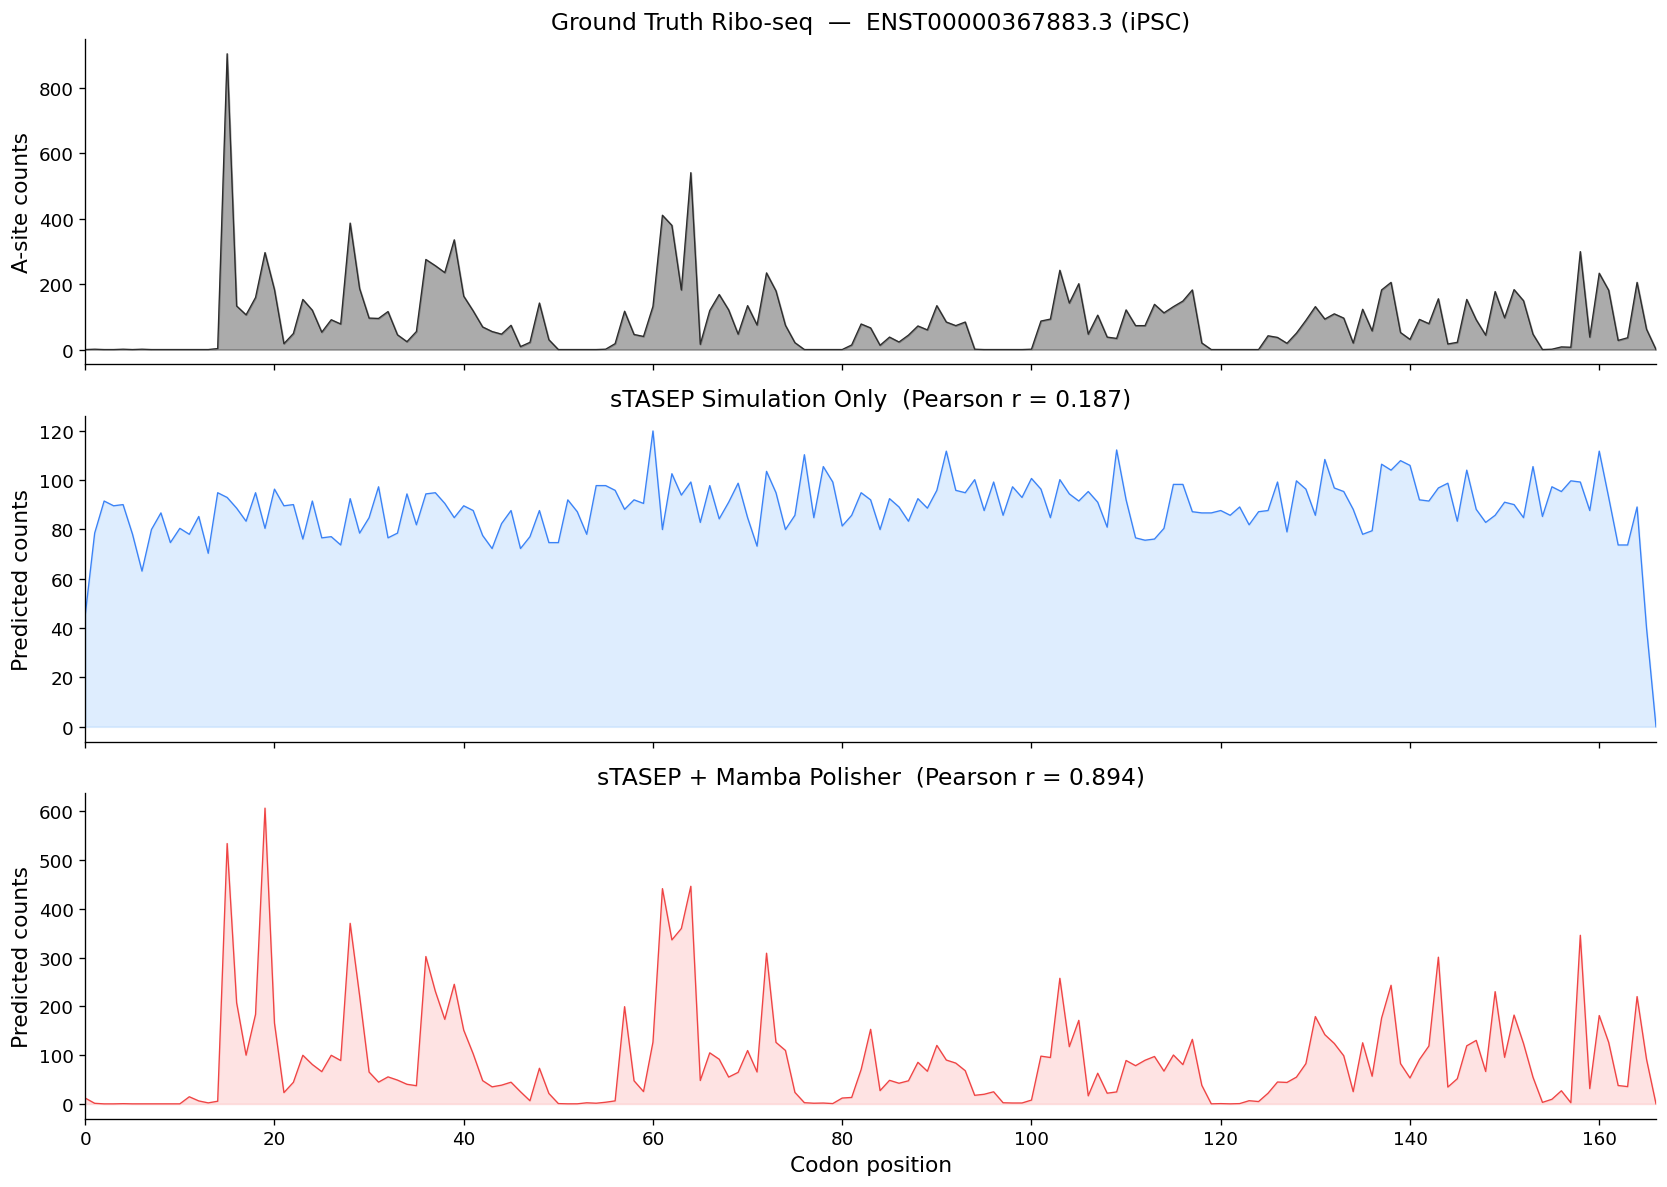

In [6]:
# Normalize for visual comparison: scale predictions to match ground-truth total
gt_total = gt_asite.sum()
stasep_scaled = pred_stasep * (gt_total / (pred_stasep.sum() + 1e-9))
polished_scaled = pred_polished * (gt_total / (pred_polished.sum() + 1e-9))

x = np.arange(n_codons)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Ground truth
axes[0].fill_between(x, gt_asite, alpha=0.4, color=COLORS["ground_truth"])
axes[0].plot(x, gt_asite, color=COLORS["ground_truth"], linewidth=0.8)
axes[0].set_ylabel("A-site counts")
axes[0].set_title(f"Ground Truth Ribo-seq  —  {sample['tx_id']} (iPSC)")

# sTASEP only
axes[1].fill_between(x, stasep_scaled, alpha=0.3, color=COLORS["stasep_fill"])
axes[1].plot(x, stasep_scaled, color=COLORS["stasep"], linewidth=0.8)
r_st, _ = pearsonr(gt_asite, stasep_scaled)
axes[1].set_ylabel("Predicted counts")
axes[1].set_title(f"sTASEP Simulation Only  (Pearson r = {r_st:.3f})")

# Polished
axes[2].fill_between(x, polished_scaled, alpha=0.3, color=COLORS["polisher_fill"])
axes[2].plot(x, polished_scaled, color=COLORS["polisher"], linewidth=0.8)
r_pol, _ = pearsonr(gt_asite, polished_scaled)
axes[2].set_ylabel("Predicted counts")
axes[2].set_title(f"sTASEP + Mamba Polisher  (Pearson r = {r_pol:.3f})")
axes[2].set_xlabel("Codon position")

for ax in axes:
    ax.set_xlim(0, n_codons - 1)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

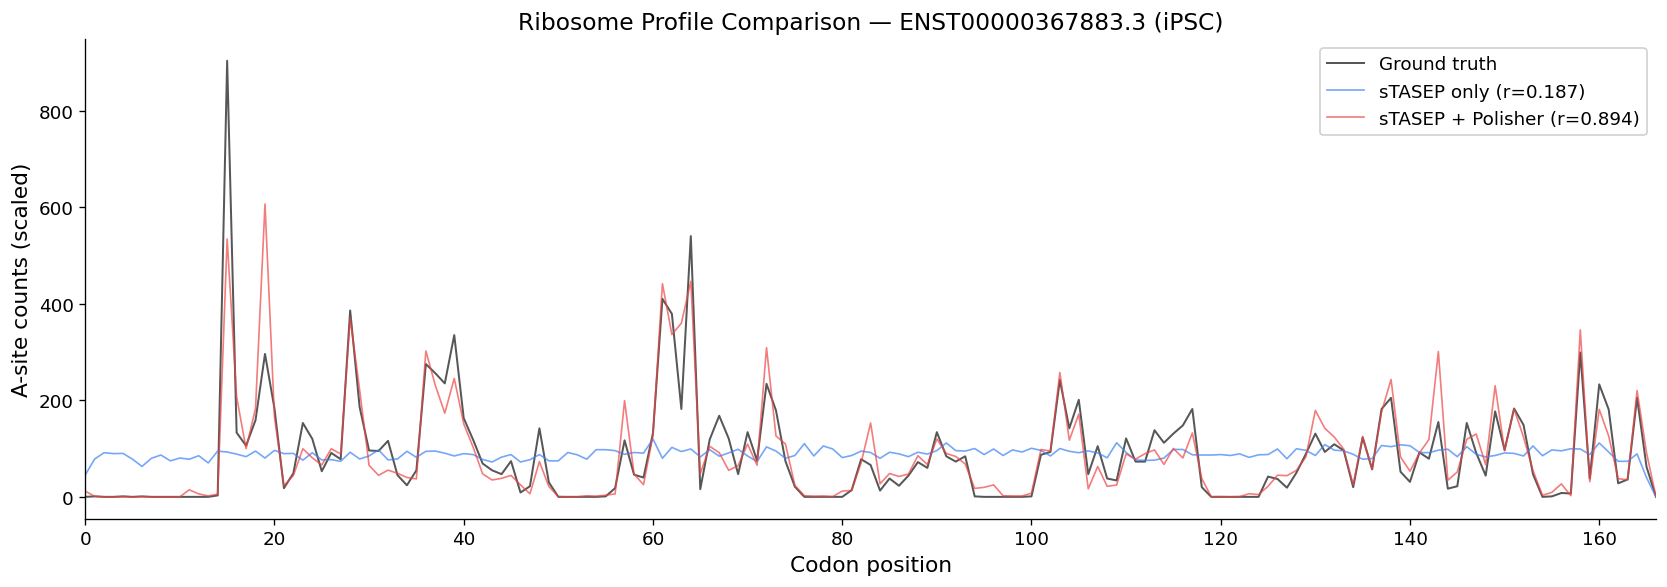

In [7]:
# Overlay comparison
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(x, gt_asite, color=COLORS["ground_truth"], linewidth=1.2, label="Ground truth", alpha=0.8)
ax.plot(x, stasep_scaled, color=COLORS["stasep"], linewidth=1.0, label=f"sTASEP only (r={r_st:.3f})", alpha=0.7)
ax.plot(x, polished_scaled, color=COLORS["polisher"], linewidth=1.0, label=f"sTASEP + Polisher (r={r_pol:.3f})", alpha=0.7)

ax.set_xlabel("Codon position")
ax.set_ylabel("A-site counts (scaled)")
ax.set_title(f"Ribosome Profile Comparison — {sample['tx_id']} (iPSC)")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_xlim(0, n_codons - 1)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 3. Cross-cell-line Comparison (All 4 Cell Lines)

The same gene can show different ribosome occupancy patterns across cell types due to differences in tRNA availability, codon usage bias, and regulatory context. seq2ribo captures this through cell-line-specific sTASEP rate parameters.

Here we run the **same transcript through all four cell lines** (HEK293, LCL, RPE-1, iPSC) and visualize the differences side by side.

**Ribosome profiles and TE** use the ribo-seq demo transcript. **Protein expression** uses a CDS from the held-out **mRFP reporter** test set (`mrfp_expr_test_samples.csv`)—the same experimental system the expression heads were trained on, not ribo-seq transcripts. Each line is a **separately trained** checkpoint (iPSC uses a narrower expression MLP; see README). Raw expression values are **not** directly comparable across lines; the protein panel uses a **log-scaled** y-axis.

In [8]:
# Initialize predictors for all four cell lines
all_cell_lines = ["ipsc", "lcl", "hek293", "rpe"]
predictors = {}
for cl in all_cell_lines:
    predictors[cl] = Seq2Ribo(cell_line=cl, weights_dir=WEIGHTS_DIR)
predictor_lcl = predictors["lcl"]

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: ipsc)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_final_unscaled.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: lcl)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/lcl_mamba_final_unscaled.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: hek293)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/hek293_mamba_final_unscaled.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: rpe)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/rpe_mamba_final_unscaled.pt...


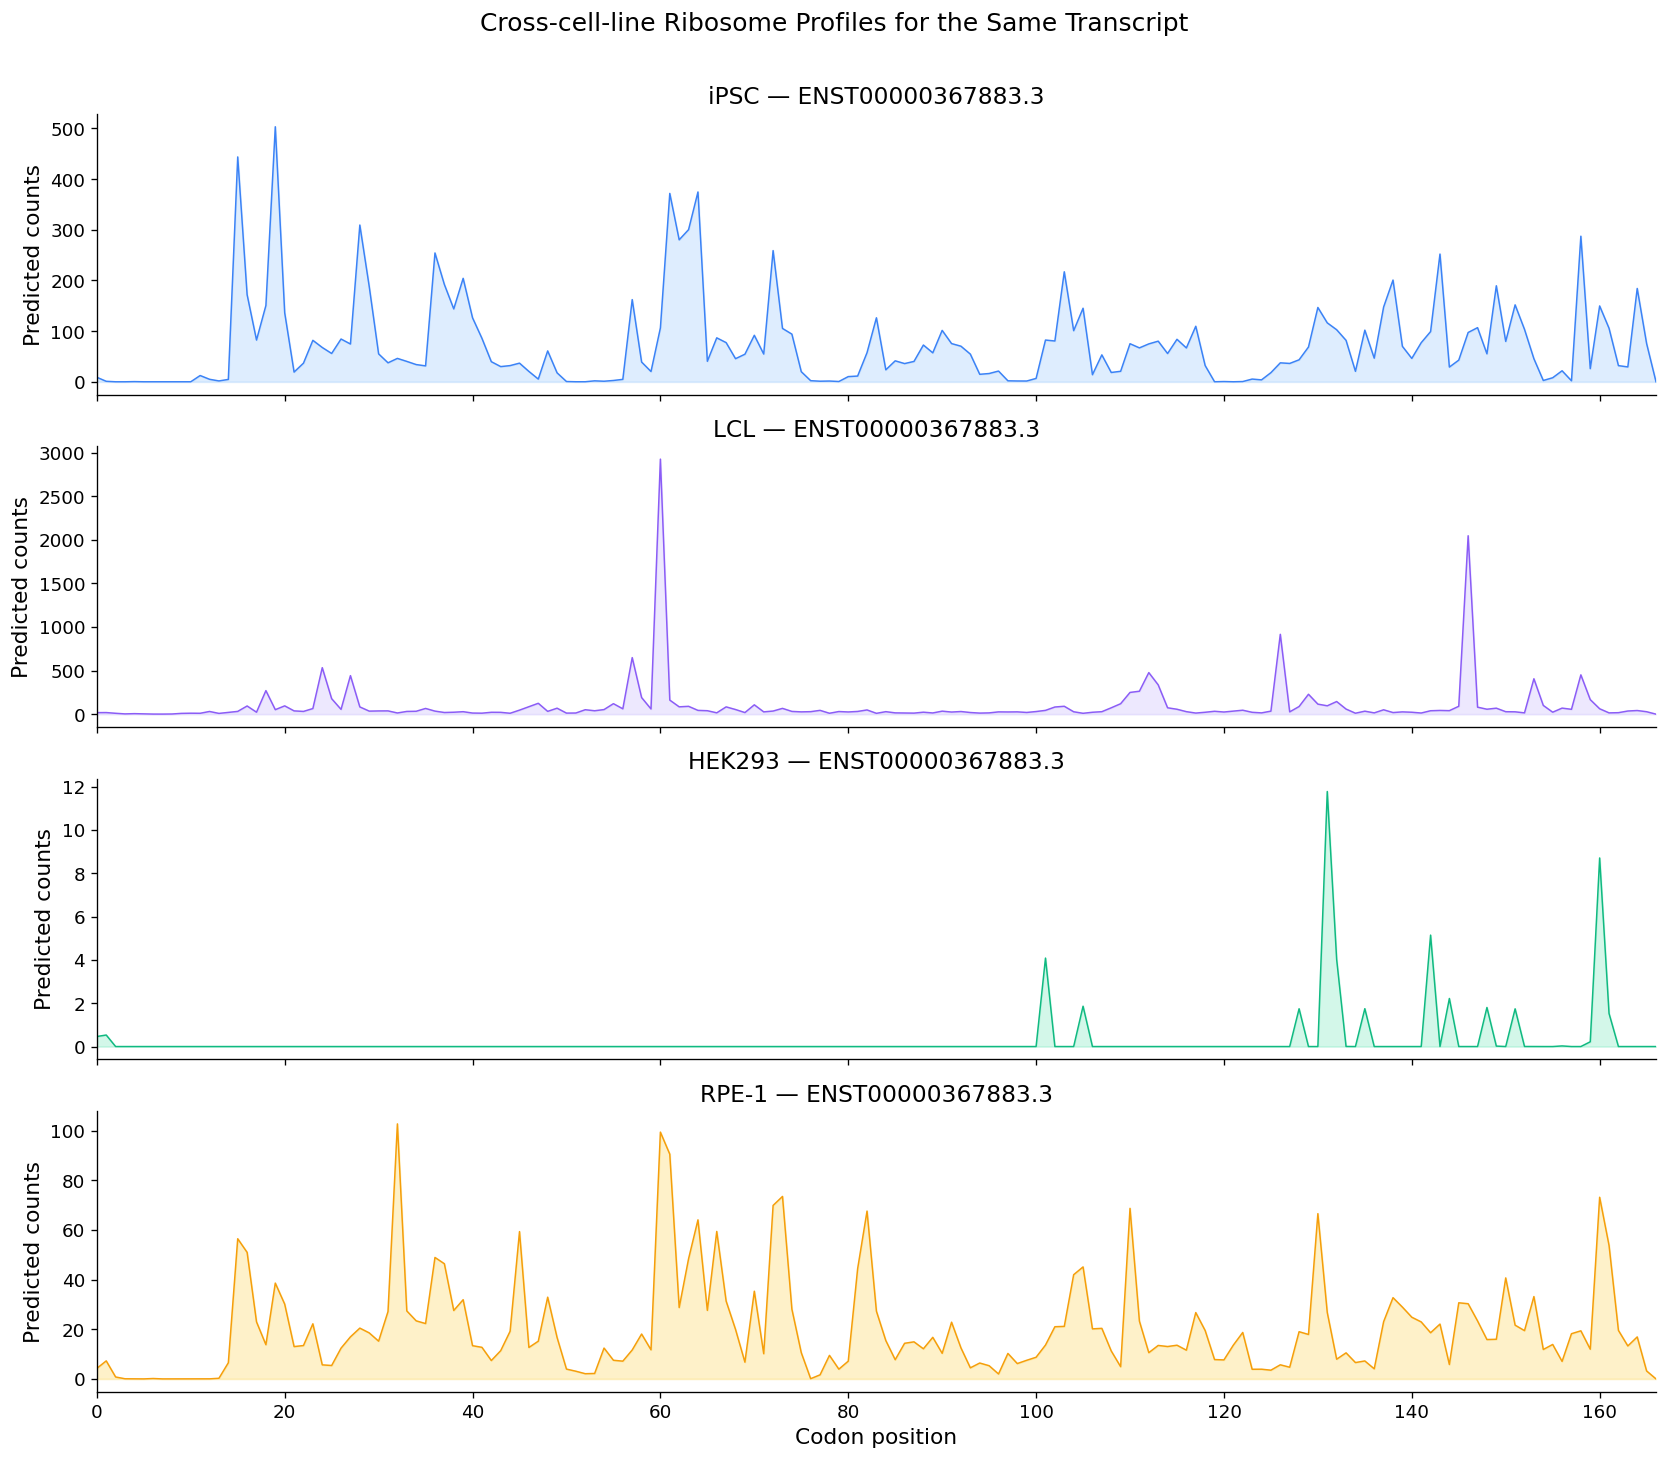

In [9]:
# Predict A-site profiles for the same transcript across all 4 cell lines
cell_preds = {}
for cl in all_cell_lines:
    cell_preds[cl] = predictors[cl].predict(
        demo_cds_seq, task="riboseq", use_polisher=True, n_stasep_runs=50
    )[0]

cell_colors = {
    "ipsc":   ("#3b82f6", "#93c5fd"),
    "lcl":    ("#8b5cf6", "#c4b5fd"),
    "hek293": ("#10b981", "#6ee7b7"),
    "rpe":    ("#f59e0b", "#fcd34d"),
}
cell_labels = {"ipsc": "iPSC", "lcl": "LCL", "hek293": "HEK293", "rpe": "RPE-1"}

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, cl in zip(axes, all_cell_lines):
    pred = cell_preds[cl]
    color, fill = cell_colors[cl]
    ax.fill_between(x, pred, alpha=0.3, color=fill)
    ax.plot(x, pred, color=color, linewidth=0.9)
    ax.set_ylabel("Predicted counts")
    ax.set_title(f"{cell_labels[cl]} — {sample['tx_id']}")
    ax.set_xlim(0, n_codons - 1)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Codon position")
fig.suptitle("Cross-cell-line Ribosome Profiles for the Same Transcript", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

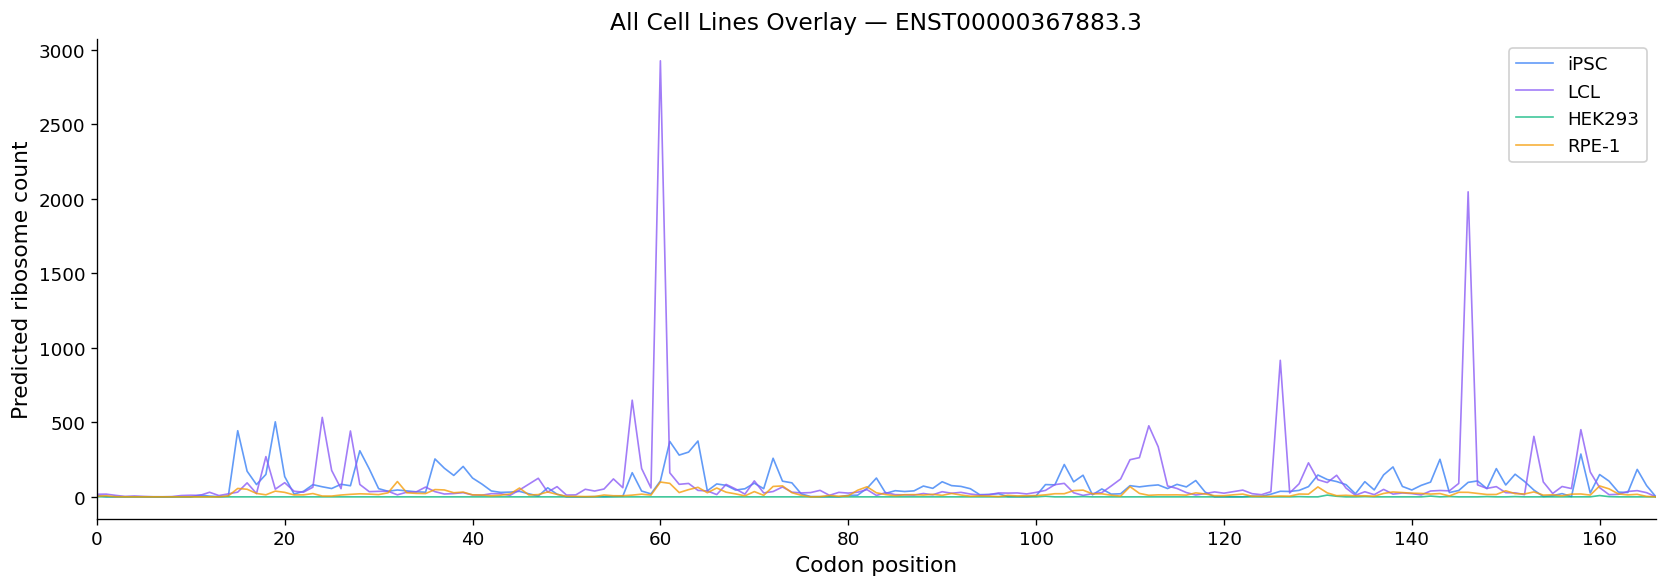

In [10]:
# Overlay all 4 cell lines on a single plot
fig, ax = plt.subplots(figsize=(14, 5))
for cl in all_cell_lines:
    color, _ = cell_colors[cl]
    ax.plot(x, cell_preds[cl], color=color, linewidth=1.0,
            label=cell_labels[cl], alpha=0.8)
ax.set_xlabel("Codon position")
ax.set_ylabel("Predicted ribosome count")
ax.set_title(f"All Cell Lines Overlay — {sample['tx_id']}")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_xlim(0, n_codons - 1)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: ipsc, use_utr=False)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_te_full_final_cds.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'protein' (Cell Line: ipsc)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_expr_full_final.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: lcl, use_utr=False)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/lcl_mamba_te_full_final_cds.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'protein' (Cell Line: lcl)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/lcl_mamba_expr_full_final.pt...
Running sTASEP simulation for 1 sequence

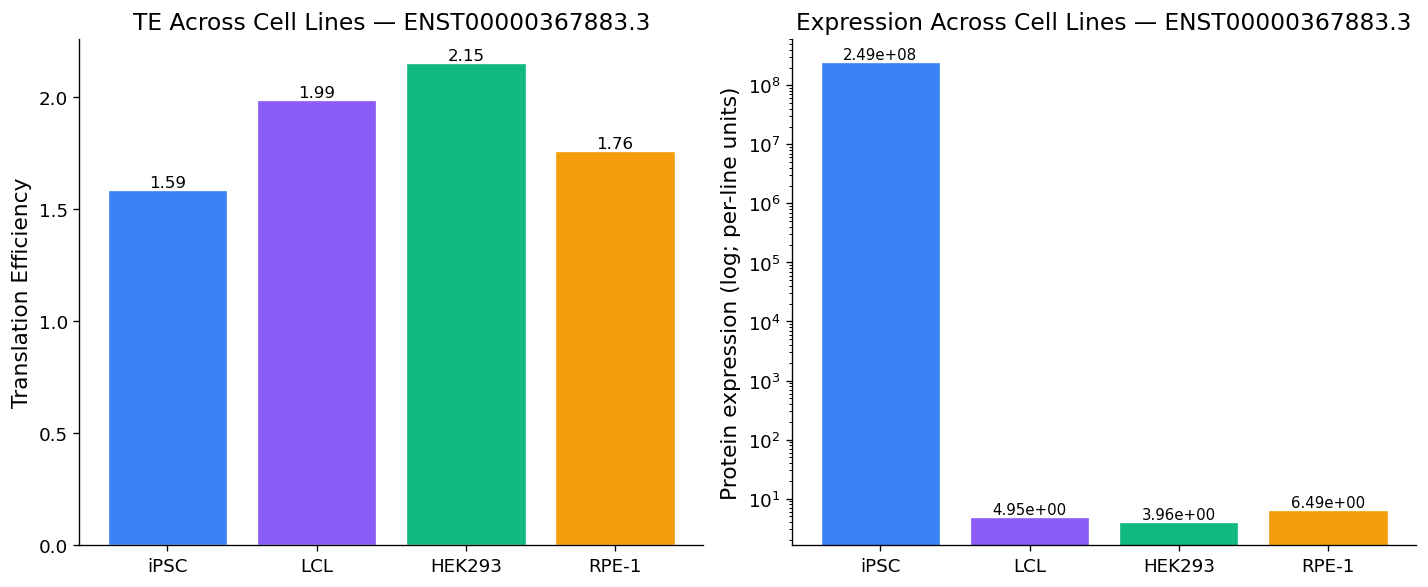

In [11]:
# TE: ribo-seq demo CDS. Protein: mRFP test-set CDS (expression head training domain).
cell_te = {}
cell_expr = {}
for cl in all_cell_lines:
    cell_te[cl] = predictors[cl].predict(demo_cds_seq, task="te", n_stasep_runs=50)[0]
    cell_expr[cl] = predictors[cl].predict(mrfp_expr_demo_seq, task="protein", n_stasep_runs=50)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

labels = [cell_labels[cl] for cl in all_cell_lines]
te_vals = [cell_te[cl] for cl in all_cell_lines]
expr_vals = [cell_expr[cl] for cl in all_cell_lines]
bar_colors = [cell_colors[cl][0] for cl in all_cell_lines]

bars1 = ax1.bar(labels, te_vals, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars1, te_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.2f}", ha="center", va="bottom", fontsize=10)
ax1.set_ylabel("Translation Efficiency")
ax1.set_title(f"TE (ribo-seq demo) — {sample['tx_id']}")
ax1.spines[["top", "right"]].set_visible(False)

bars2 = ax2.bar(labels, expr_vals, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars2, expr_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.2e}", ha="center", va="bottom", fontsize=9)
ax2.set_yscale("log")
ax2.set_ylabel("Protein expression (log; per-line units)")
ax2.set_title(f"Expression (mRFP test CDS) — {mrfp_expr_demo_label}")
ax2.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 4. Translation Efficiency (TE) — CDS Only

Translation efficiency measures how effectively an mRNA is translated into protein, relative to its abundance. seq2ribo predicts TE as a scalar value from the coding sequence (CDS).

The model outputs a value in [0, 1] which is then inverse-transformed back to the original TE scale.

In [12]:
# Collect CDS sequences from all iPSC demo transcripts
ipsc_transcripts = [
    demo_data[k] for k in sorted(demo_data.keys()) if k[0] == "ipsc"
]
tx_names = [d["tx_id"] for d in ipsc_transcripts]
tx_seqs = [d["sequence"] for d in ipsc_transcripts]

# Predict TE (inverse-transformed, real TE scale)
te_values = predictor_ipsc.predict(tx_seqs, task="te", n_stasep_runs=50)

# Also get scaled [0,1] values
te_scaled = predictor_ipsc.predict(tx_seqs, task="te", n_stasep_runs=50, return_scaled_te=True)

print(f"{'Transcript':<28s} {'TE (original scale)':>20s} {'TE (scaled 0-1)':>18s}")
print("-" * 70)
for name, te, te_s in zip(tx_names, te_values, te_scaled):
    print(f"{name:<28s} {te:>20.4f} {te_s:>18.4f}")

Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: ipsc, use_utr=False)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_te_full_final_cds.pt...
Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Transcript                    TE (original scale)    TE (scaled 0-1)
----------------------------------------------------------------------
ENST00000367883.3                          1.3416             0.6496
ENST00000572154.1                          1.5891             0.6895
ENST00000649490.1                          1.9858             0.7550


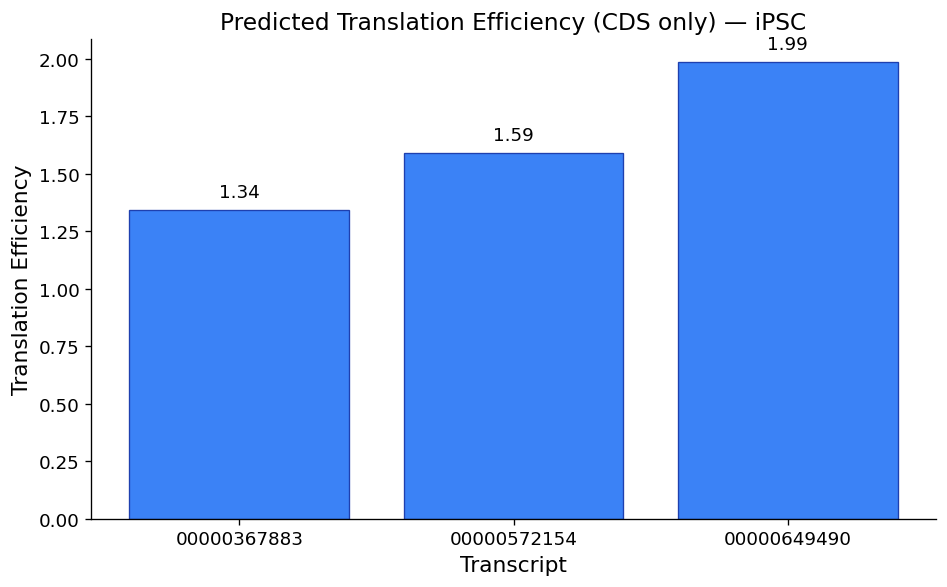

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

short_names = [n.split(".")[0].replace("ENST", "") for n in tx_names]
bars = ax.bar(short_names, te_values, color="#3b82f6", edgecolor="#1e40af", linewidth=0.8)

for bar, val in zip(bars, te_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02 * max(te_values),
            f"{val:.2f}", ha="center", va="bottom", fontsize=11)

ax.set_xlabel("Transcript")
ax.set_ylabel("Translation Efficiency")
ax.set_title("Predicted Translation Efficiency (CDS only) — iPSC")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 5. Translation Efficiency (TE) — CDS + UTR Context

UTR sequences (5′ and 3′ untranslated regions) influence translation initiation and stability. seq2ribo can incorporate UTR context for a more complete TE prediction.

In UTR-aware mode, you provide the 5′ UTR, CDS, and 3′ UTR as separate inputs.

In [14]:
# Example UTR sequences (representative lengths)
utr5_seqs = [
    "GCUCUCCGACUCCGGCGCGGCGCCCCGACUCCGGUACAGCCGUUCCGCCCACGCUCCGAC",
    "AGACCUGGCUGCUCUGAACAGCUCCGGCCUUA",
    "CCCGCCGGAGCCAUGUCUAUCAUGC",
]
cds_seqs = [d["sequence"] for d in ipsc_transcripts]
utr3_seqs = [
    "CCAGCUCCUGGUACCCUGGCACCUGUAAUAAUUUGUGUUCCUUCUAAAAGGUAAA",
    "UUAUCUAAAUUGUACAAAGGUAAUAAACUGUUGUUUCUAAUAAAUACAGACUAUUU",
    "CCUAAUAAAGAUCACUUUUAUAUCAAAUGUUUCA",
]

# CDS-only TE
te_cds = predictor_ipsc.predict(cds_seqs, task="te", n_stasep_runs=50)

# CDS + UTR TE
te_utr = predictor_ipsc.predict(
    task="te", use_utr=True,
    utr5_list=utr5_seqs, cds_list=cds_seqs, utr3_list=utr3_seqs,
    n_stasep_runs=50,
)

print(f"{'Transcript':<28s} {'TE (CDS)':>12s} {'TE (CDS+UTR)':>14s}")
print("-" * 58)
for name, t_cds, t_utr in zip(tx_names, te_cds, te_utr):
    print(f"{name:<28s} {t_cds:>12.4f} {t_utr:>14.4f}")

Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: ipsc, use_utr=True)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_te_utr_final.pt...
Transcript                       TE (CDS)   TE (CDS+UTR)
----------------------------------------------------------
ENST00000367883.3                  1.3427         1.5588
ENST00000572154.1                  1.5871         2.0356
ENST00000649490.1                  1.9918         1.3846


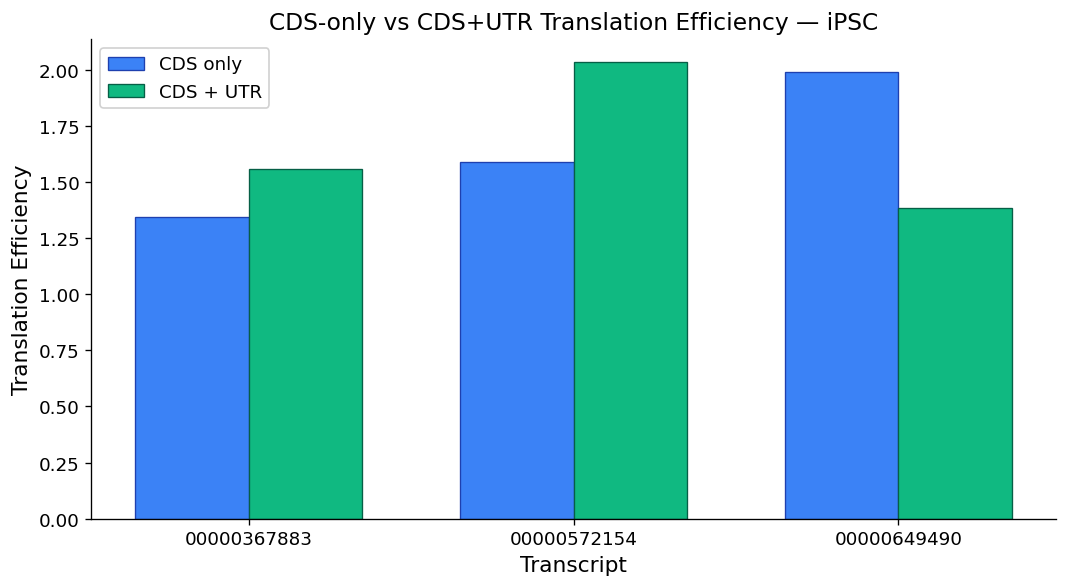

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

bar_width = 0.35
indices = np.arange(len(tx_names))

ax.bar(indices - bar_width / 2, te_cds, bar_width, label="CDS only",
       color="#3b82f6", edgecolor="#1e40af", linewidth=0.8)
ax.bar(indices + bar_width / 2, te_utr, bar_width, label="CDS + UTR",
       color="#10b981", edgecolor="#065f46", linewidth=0.8)

ax.set_xticks(indices)
ax.set_xticklabels(short_names)
ax.set_xlabel("Transcript")
ax.set_ylabel("Translation Efficiency")
ax.set_title("CDS-only vs CDS+UTR Translation Efficiency — iPSC")
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 6. Protein Expression Prediction

The **protein-expression** checkpoints were trained on **mRFP fluorescent reporter** data (CDS variants), not ribo-seq. Below, predictions use **held-out test** sequences from `sample_data/mrfp_expr_test_samples.csv` (subset of the public mRFP expression benchmark).

Inference uses **Monte Carlo dropout** (32 stochastic forward passes). Outputs are **model-specific units**; do not compare raw values across cell-line checkpoints—only within one trained model.

In [16]:
# mRFP test-set variants (expression head training domain)
mrfp_expr_names = [f"mRFP-test-{i}" for i in range(len(mrfp_expr_df))]
mrfp_expr_seqs = mrfp_expr_df["Sequence"].tolist()
expr_values = predictor_ipsc.predict(mrfp_expr_seqs, task="protein", n_stasep_runs=50)

print(f"{'mRFP variant':<28s} {'Protein Expression':>20s}")
print("-" * 50)
for name, expr in zip(mrfp_expr_names, expr_values):
    print(f"{name:<28s} {expr:>20.4f}")

Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'protein' (Cell Line: ipsc)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_expr_full_final.pt...
Transcript                     Protein Expression
--------------------------------------------------
ENST00000367883.3                  231774624.0000
ENST00000572154.1                  248434784.0000
ENST00000649490.1                  149188256.0000


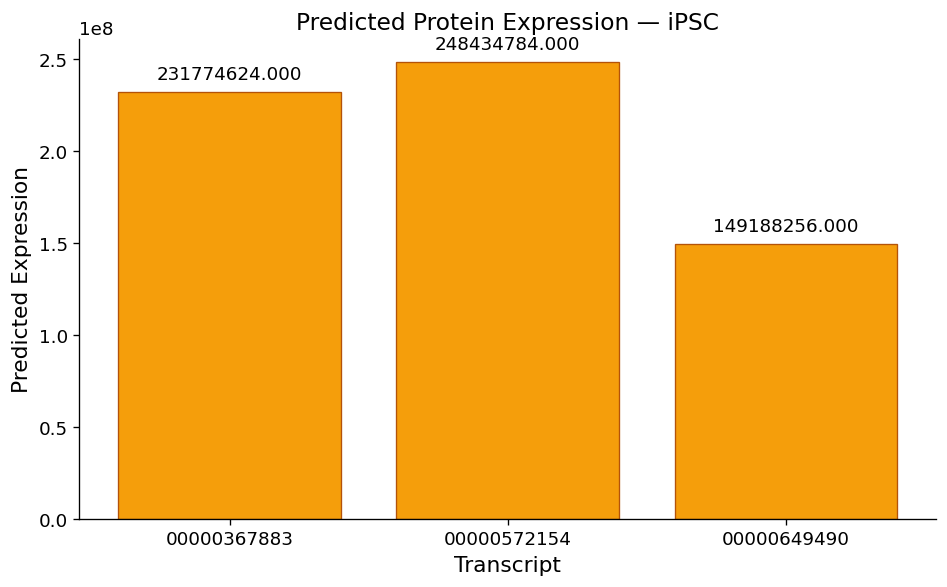

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

mrfp_short = [f"T{i}" for i in range(len(mrfp_expr_df))]
bars = ax.bar(mrfp_short, expr_values, color="#f59e0b", edgecolor="#b45309", linewidth=0.8)

for bar, val in zip(bars, expr_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02 * max(expr_values),
            f"{val:.3f}", ha="center", va="bottom", fontsize=11)

ax.set_xlabel("mRFP test variant")
ax.set_ylabel("Predicted Expression")
ax.set_title("Predicted protein expression (mRFP test CDS) — iPSC")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 7. Try Your Own Sequence

Paste an RNA coding sequence (CDS) below to generate predictions. The sequence must:
- Start with a start codon (AUG)
- End with a stop codon (UAA, UAG, or UGA)
- Have a length that is a multiple of 3 (complete codons)
- Use RNA alphabet (A, U, G, C) — T is automatically converted to U

In [18]:
# === PASTE YOUR RNA CDS SEQUENCE HERE ===
my_sequence = "AUGGCCAAGCUGAAGAAGGCCACCUUCGGCUUCAGCGAGGGCACCAAGGUGCUGUUCC" \
              "AGCCAUCCAUGUCCGUGUCCUUCGACAAGUUCGAGAAGGACGGCGACAUGGCCAUGGA" \
              "GUCCCUGAAGGCCAUCUGCACCGACAACUUCUCCUGGAACCACCUGGUGGAGCUGCAC" \
              "GGCAAGCAGGAGUUCGAGAGCAUGGGCGCCGACUGGAAUAACAUUGCUAAGAUCAUCU" \
              "UCGAGGGCCUCGGCUUCAAGAAGGACGGCAACCCAAUCCCCAACCCAGAGCUCAAGGCC" \
              "AUCGGCAAGAAGGUGGGCCCUGACAACGACCAGUAA"

cell_line = "ipsc"  # Change to: "hek293", "lcl", "rpe", or "ipsc"

# ==========================================

predictor = Seq2Ribo(cell_line=cell_line, weights_dir=WEIGHTS_DIR)

# Run all three prediction tasks
profile_stasep = predictor.predict(my_sequence, task="riboseq", use_polisher=False, n_stasep_runs=50)[0]
profile_polished = predictor.predict(my_sequence, task="riboseq", use_polisher=True, n_stasep_runs=50)[0]
te_value = predictor.predict(my_sequence, task="te", n_stasep_runs=50)[0]
expr_value = predictor.predict(my_sequence, task="protein", n_stasep_runs=50)[0]

n_cod = len(my_sequence.replace("T", "U").replace("t", "u")) // 3
print(f"Sequence length: {n_cod} codons")
print(f"Translation Efficiency: {te_value:.4f}")
print(f"Protein Expression:     {expr_value:.4f}")

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: ipsc)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_final_unscaled.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: ipsc, use_utr=False)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_te_full_final_cds.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'protein' (Cell Line: ipsc)...
Loading weights from /mnt/disk90/user/gkaynar/seq2ribo/weights/ipsc_mamba_expr_full_final.pt...
Sequence length: 109 codons
Translation Efficiency: 1.9278
Protein Expression:     182565728.0000


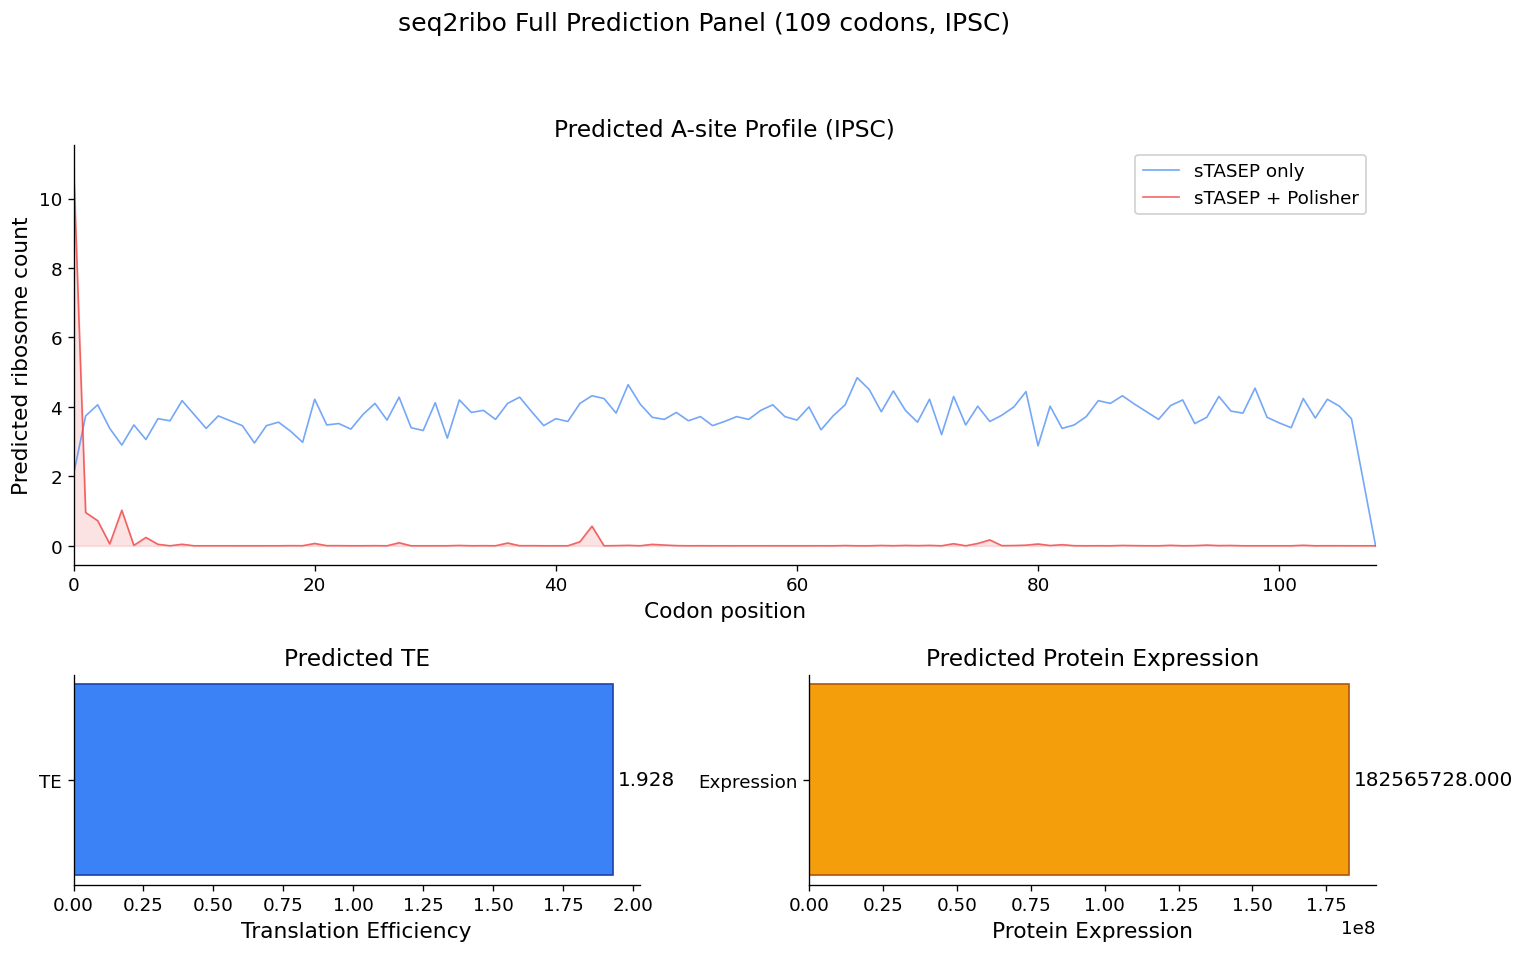

In [19]:
# Full visualization panel for your sequence
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.35, wspace=0.3)

# Top: A-site profile
ax_profile = fig.add_subplot(gs[0, :])
xp = np.arange(n_cod)
ax_profile.plot(xp, profile_stasep, color=COLORS["stasep"], linewidth=1.0, label="sTASEP only", alpha=0.7)
ax_profile.plot(xp, profile_polished, color=COLORS["polisher"], linewidth=1.0, label="sTASEP + Polisher", alpha=0.8)
ax_profile.fill_between(xp, profile_polished, alpha=0.15, color=COLORS["polisher"])
ax_profile.set_xlabel("Codon position")
ax_profile.set_ylabel("Predicted ribosome count")
ax_profile.set_title(f"Predicted A-site Profile ({cell_line.upper()})")
ax_profile.legend(loc="upper right", framealpha=0.9)
ax_profile.set_xlim(0, n_cod - 1)
ax_profile.spines[["top", "right"]].set_visible(False)

# Bottom left: TE
ax_te = fig.add_subplot(gs[1, 0])
ax_te.barh(["TE"], [te_value], color="#3b82f6", edgecolor="#1e40af", height=0.5)
ax_te.set_xlabel("Translation Efficiency")
ax_te.set_title("Predicted TE")
ax_te.text(te_value + 0.01 * abs(te_value), 0, f"{te_value:.3f}", va="center", fontsize=12)
ax_te.spines[["top", "right"]].set_visible(False)

# Bottom right: Protein expression
ax_expr = fig.add_subplot(gs[1, 1])
ax_expr.barh(["Expression"], [expr_value], color="#f59e0b", edgecolor="#b45309", height=0.5)
ax_expr.set_xlabel("Protein Expression")
ax_expr.set_title("Predicted Protein Expression")
ax_expr.text(expr_value + 0.01 * abs(expr_value), 0, f"{expr_value:.3f}", va="center", fontsize=12)
ax_expr.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"seq2ribo Full Prediction Panel ({n_cod} codons, {cell_line.upper()})", fontsize=15, y=1.02)
plt.show()

---
## 8. Batch Prediction from FASTA

Process multiple sequences at once by reading from a FASTA file. The example file uses **mRFP test-set** CDS sequences so the **expression** column matches the protein head’s training domain (TE is still reported on the same sequences).

In [20]:
def read_fasta(path):
    """Simple FASTA reader returning list of (header, sequence) tuples."""
    sequences = []
    header, seq_parts = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    sequences.append((header, "".join(seq_parts)))
                header = line[1:].split()[0]
                seq_parts = []
            elif line:
                seq_parts.append(line)
    if header is not None:
        sequences.append((header, "".join(seq_parts)))
    return sequences

# Example FASTA: mRFP expression test variants (protein head training domain)
example_fasta = Path("sample_data/example_batch.fa")
with open(example_fasta, "w") as f:
    for k, (_, row) in enumerate(mrfp_expr_df.head(3).iterrows()):
        f.write(f">mRFP_test_{k}\n")
        cds_write = row["Sequence"]
        for j in range(0, len(cds_write), 80):
            f.write(cds_write[j:j+80] + "\n")

print(f"Wrote 3 mRFP test sequences to {example_fasta}")

Wrote 3 sequences to sample_data/example_batch.fa


In [21]:
# Read FASTA and run batch predictions
fasta_seqs = read_fasta(example_fasta)
headers = [h for h, _ in fasta_seqs]
sequences = [s for _, s in fasta_seqs]

batch_te = predictor_ipsc.predict(sequences, task="te", n_stasep_runs=50)
batch_expr = predictor_ipsc.predict(sequences, task="protein", n_stasep_runs=50)

print(f"{'Sample':<28s} {'Codons':>8s} {'TE':>10s} {'Expression':>12s}")
print("=" * 62)
for header, fa_seq, te, expr in zip(headers, sequences, batch_te, batch_expr):
    n = len(fa_seq) // 3
    print(f"{header:<28s} {n:>8d} {te:>10.4f} {expr:>12.4f}")

Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Transcript                     Codons         TE   Expression
ENST00000367883.3                 167     1.3410 231772688.0000
ENST00000572154.1                  40     1.5892 248659264.0000
ENST00000649490.1                 325     1.9864 149635120.0000


---
## 9. Synonymous Codon Mutation Analysis

Different codons encode the same amino acid but are decoded at different speeds by the ribosome. Replacing a codon with a synonymous alternative changes the **local ribosome density** without altering the protein sequence.

This is directly relevant for **codon optimization** in synthetic biology and mRNA therapeutics. Below we replace **CUG → UUA** at every leucine CUG in the demo CDS (one clear direction; amino acid stays leucine). We plot **sTASEP-only** profiles, then **sTASEP + Mamba polisher** (with TE from the neural head on the polished path), then a **direct overlay** of both (normalized to unit area so shapes are comparable).

In [22]:
# Synonymous codon table (amino acid -> list of codons)
CODON_TABLE = {
    "F": ["UUU", "UUC"], "L": ["UUA", "UUG", "CUU", "CUC", "CUA", "CUG"],
    "I": ["AUU", "AUC", "AUA"], "M": ["AUG"], "V": ["GUU", "GUC", "GUA", "GUG"],
    "S": ["UCU", "UCC", "UCA", "UCG", "AGU", "AGC"],
    "P": ["CCU", "CCC", "CCA", "CCG"], "T": ["ACU", "ACC", "ACA", "ACG"],
    "A": ["GCU", "GCC", "GCA", "GCG"], "Y": ["UAU", "UAC"],
    "H": ["CAU", "CAC"], "Q": ["CAA", "CAG"], "N": ["AAU", "AAC"],
    "K": ["AAA", "AAG"], "D": ["GAU", "GAC"], "E": ["GAA", "GAG"],
    "C": ["UGU", "UGC"], "W": ["UGG"], "R": ["CGU", "CGC", "CGA", "CGG", "AGA", "AGG"],
    "G": ["GGU", "GGC", "GGA", "GGG"], "*": ["UAA", "UAG", "UGA"],
}
CODON_TO_AA = {cod: aa for aa, cods in CODON_TABLE.items() for cod in cods}

def get_synonymous(codon):
    """Return all synonymous codons for a given codon (excluding itself)."""
    aa = CODON_TO_AA.get(codon, None)
    if aa is None:
        return []
    return [c for c in CODON_TABLE[aa] if c != codon]

def mutate_codons(seq, positions, replacements):
    """Replace codons at given positions with specified replacements."""
    codons = [seq[i:i+3] for i in range(0, len(seq), 3)]
    for pos, repl in zip(positions, replacements):
        codons[pos] = repl
    return "".join(codons)

# Use the demo CDS (stable handle — do not rely on `seq` after FASTA cells)
wt_seq = demo_cds_seq
wt_codons = [wt_seq[i:i+3] for i in range(0, len(wt_seq), 3)]

# One-direction synonymous change: CUG (Leu) → UUA (Leu). Easy to interpret;
# avoids mixing CUG→UUA and UUA→CUG in the same construct.
mut_positions = []
mut_replacements = []
for i, cod in enumerate(wt_codons):
    if cod == "CUG":
        mut_positions.append(i)
        mut_replacements.append("UUA")

if not mut_positions:
    for i, cod in enumerate(wt_codons):
        if cod in CODON_TABLE["L"] and cod != "UUA":
            mut_positions = [i]
            mut_replacements = ["UUA"]
            print("No CUG in this CDS; demo uses first non-UUA leucine → UUA.")
            break

mut_seq = mutate_codons(wt_seq, mut_positions, mut_replacements)
print(f"Wild-type sequence: {len(wt_codons)} codons")
print(f"Synonymous mutations: {len(mut_positions)} codon(s) → UUA (leucine unchanged)")
print(f"Mutation positions: {mut_positions[:20]}{'...' if len(mut_positions) > 20 else ''}")

Wild-type sequence: 167 codons
Synonymous mutations: 3 codon(s) → UUA (leucine unchanged)
Mutation positions: [102, 130, 136]


### sTASEP only (physics simulation)

Averaged ribosome occupancy from the **sTASEP** simulator alone (`use_polisher=False`), same setting as the middle panel in §2.


Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...


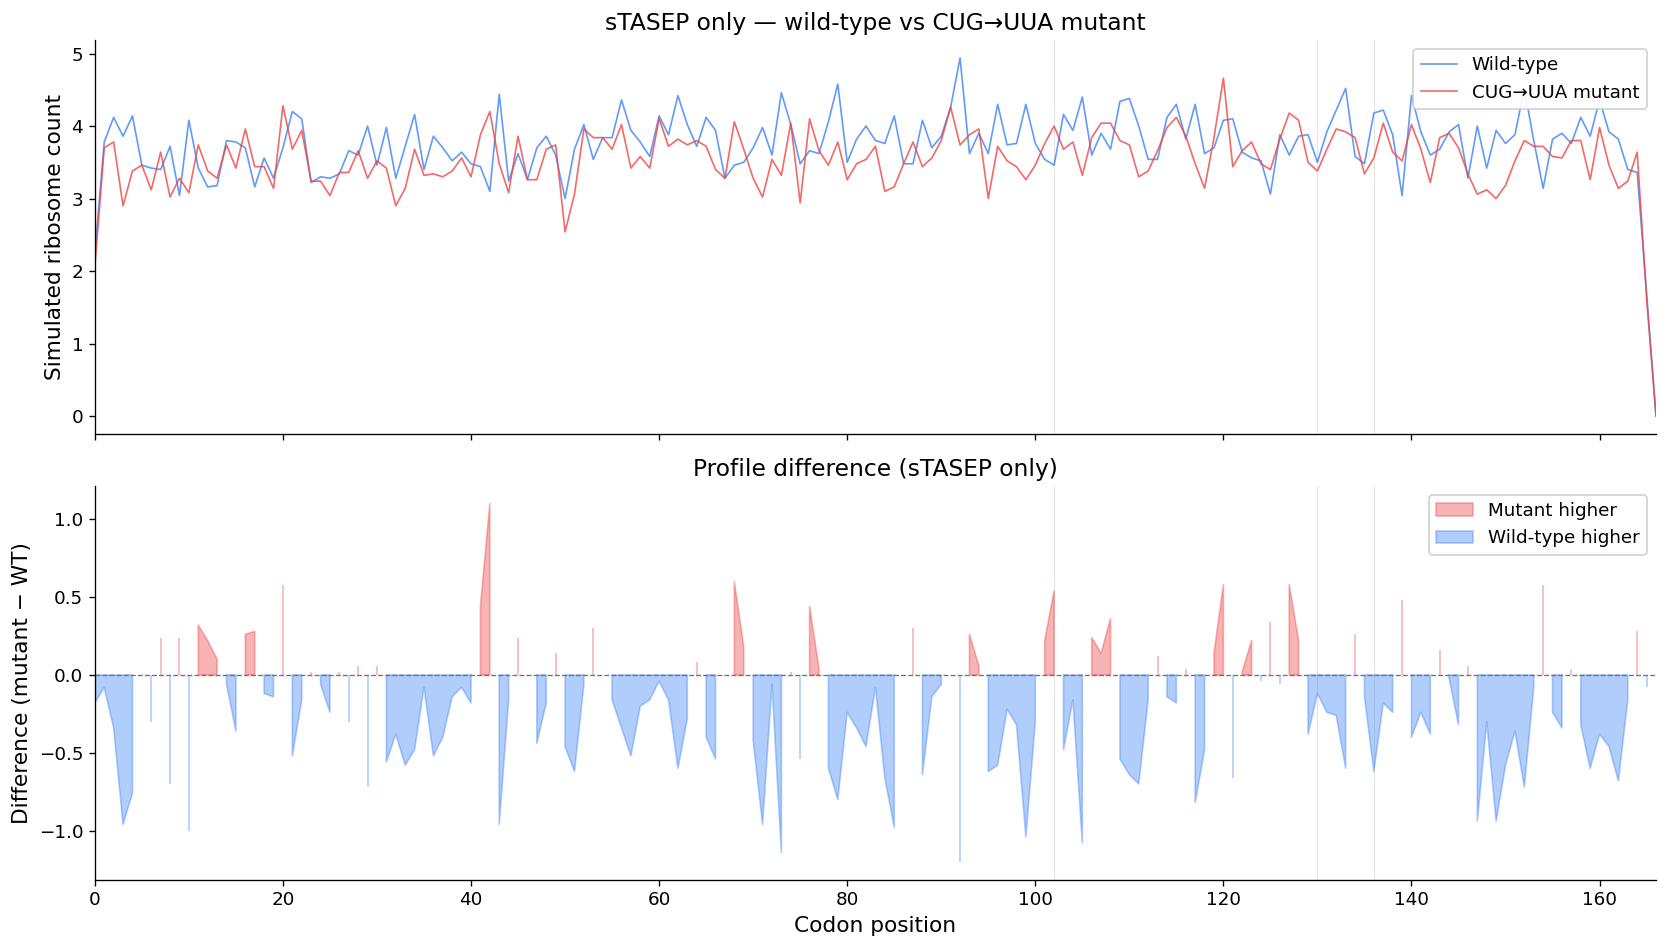


Gray vertical lines mark the 3 mutated codon positions.


In [23]:
# sTASEP simulation only (same averaged physics output as §2 "sTASEP only"; no Mamba polisher)
wt_raw = predictor_ipsc.predict(wt_seq, task="riboseq", use_polisher=False, n_stasep_runs=50)[0]
mut_raw = predictor_ipsc.predict(mut_seq, task="riboseq", use_polisher=False, n_stasep_runs=50)[0]

x_syn = np.arange(len(wt_raw))
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(x_syn, wt_raw, color="#3b82f6", linewidth=1.0, label="Wild-type", alpha=0.8)
axes[0].plot(x_syn, mut_raw, color="#ef4444", linewidth=1.0, label="CUG→UUA mutant", alpha=0.8)
for pos in mut_positions:
    axes[0].axvline(pos, color="#d4d4d4", linewidth=0.4, zorder=0)
axes[0].set_ylabel("Simulated ribosome count")
axes[0].set_title("sTASEP only — wild-type vs CUG→UUA mutant")
axes[0].legend(loc="upper right", framealpha=0.9)
axes[0].set_xlim(0, len(x_syn) - 1)
axes[0].spines[["top", "right"]].set_visible(False)

diff_raw = mut_raw - wt_raw
axes[1].fill_between(x_syn, diff_raw, where=(diff_raw > 0), color="#ef4444", alpha=0.4, label="Mutant higher")
axes[1].fill_between(x_syn, diff_raw, where=(diff_raw < 0), color="#3b82f6", alpha=0.4, label="Wild-type higher")
axes[1].axhline(0, color="#737373", linewidth=0.8, linestyle="--")
for pos in mut_positions:
    axes[1].axvline(pos, color="#d4d4d4", linewidth=0.4, zorder=0)
axes[1].set_ylabel("Difference (mutant − WT)")
axes[1].set_xlabel("Codon position")
axes[1].set_title("Profile difference (sTASEP only)")
axes[1].legend(loc="upper right", framealpha=0.9)
axes[1].set_xlim(0, len(x_syn) - 1)
axes[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()
print(f"\nGray vertical lines mark the {len(mut_positions)} mutated codon positions.")

### Polished: sTASEP + Mamba polisher

The same sTASEP simulation feeds the **Mamba polisher** (neural refinement of per-codon counts). **Translation efficiency** below uses the neural TE head on this full path (`use_polisher=True`).


Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...


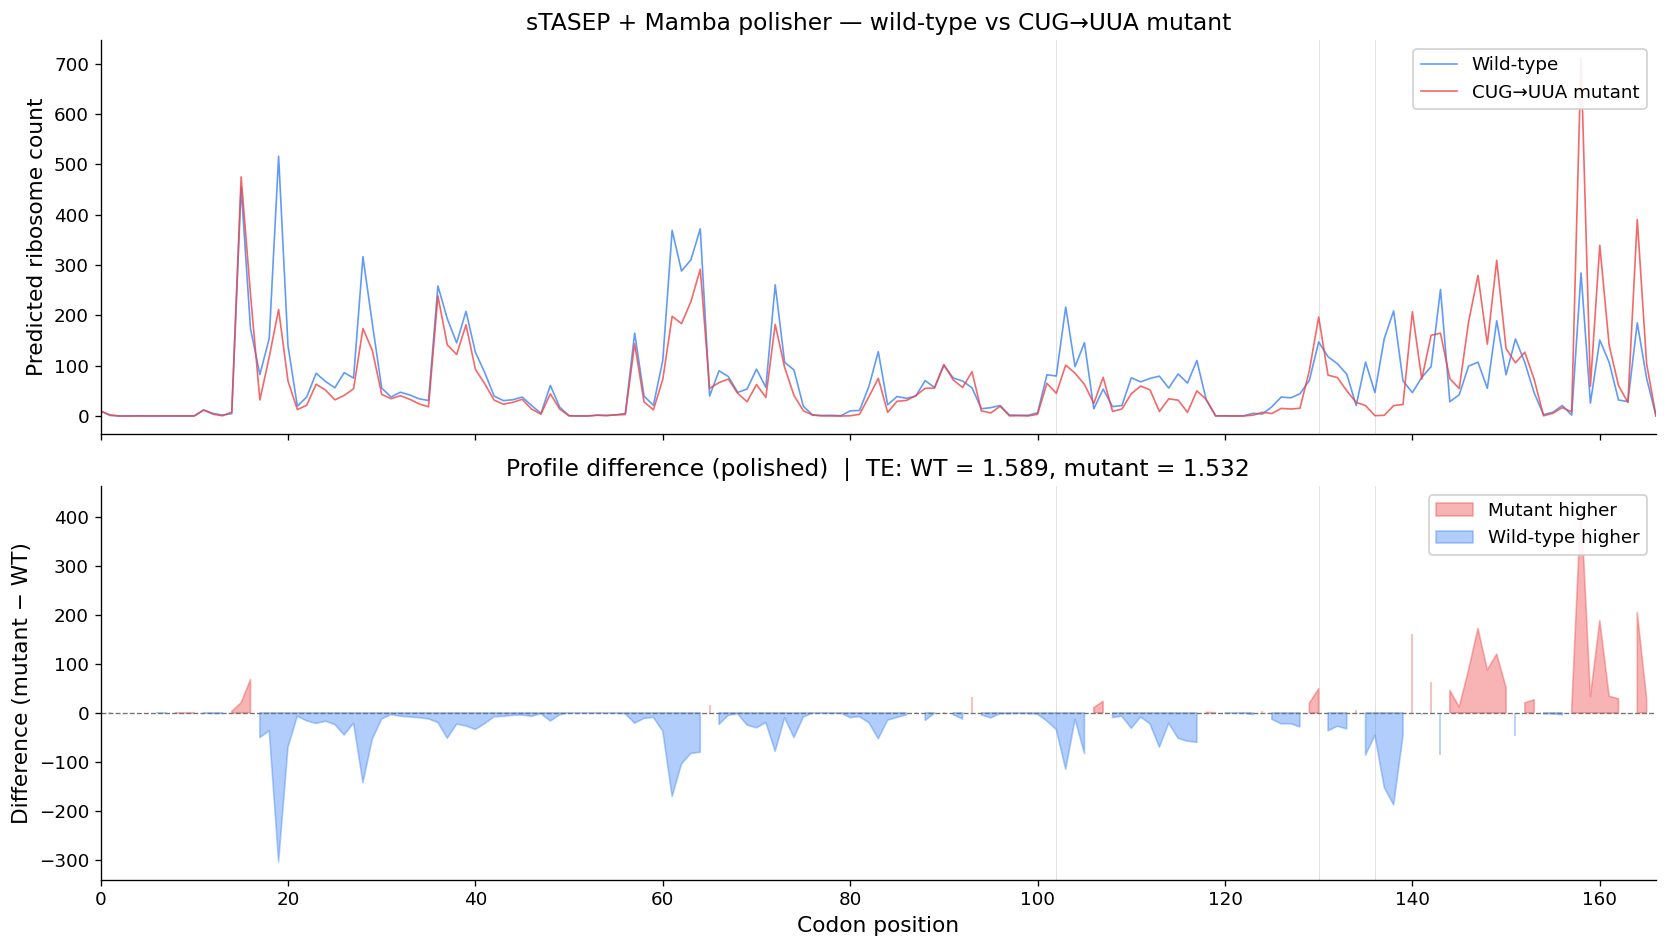

In [24]:
# Polished riboseq profiles + TE (neural heads on top of sTASEP features)
wt_profile = predictor_ipsc.predict(wt_seq, task="riboseq", use_polisher=True, n_stasep_runs=50)[0]
mut_profile = predictor_ipsc.predict(mut_seq, task="riboseq", use_polisher=True, n_stasep_runs=50)[0]

wt_te = predictor_ipsc.predict(wt_seq, task="te", n_stasep_runs=50)[0]
mut_te = predictor_ipsc.predict(mut_seq, task="te", n_stasep_runs=50)[0]

x_pol = np.arange(len(wt_profile))
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(x_pol, wt_profile, color="#3b82f6", linewidth=1.0, label="Wild-type", alpha=0.8)
axes[0].plot(x_pol, mut_profile, color="#ef4444", linewidth=1.0, label="CUG→UUA mutant", alpha=0.8)
for pos in mut_positions:
    axes[0].axvline(pos, color="#d4d4d4", linewidth=0.4, zorder=0)
axes[0].set_ylabel("Predicted ribosome count")
axes[0].set_title("sTASEP + Mamba polisher — wild-type vs CUG→UUA mutant")
axes[0].legend(loc="upper right", framealpha=0.9)
axes[0].set_xlim(0, len(x_pol) - 1)
axes[0].spines[["top", "right"]].set_visible(False)

diff_pol = mut_profile - wt_profile
axes[1].fill_between(x_pol, diff_pol, where=(diff_pol > 0), color="#ef4444", alpha=0.4, label="Mutant higher")
axes[1].fill_between(x_pol, diff_pol, where=(diff_pol < 0), color="#3b82f6", alpha=0.4, label="Wild-type higher")
axes[1].axhline(0, color="#737373", linewidth=0.8, linestyle="--")
for pos in mut_positions:
    axes[1].axvline(pos, color="#d4d4d4", linewidth=0.4, zorder=0)
axes[1].set_ylabel("Difference (mutant − WT)")
axes[1].set_xlabel("Codon position")
axes[1].set_title(f"Profile difference (polished)  |  TE: WT = {wt_te:.3f}, mutant = {mut_te:.3f}")
axes[1].legend(loc="upper right", framealpha=0.9)
axes[1].set_xlim(0, len(x_pol) - 1)
axes[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

### sTASEP vs polisher (overlay)

The two panels above use different vertical scales. Here, **sTASEP-only** and **polished** curves are **normalized to sum to 1** so you can compare shape on the same axes (run the two code cells above first so `wt_raw` / `mut_raw` / `wt_profile` / `mut_profile` exist).


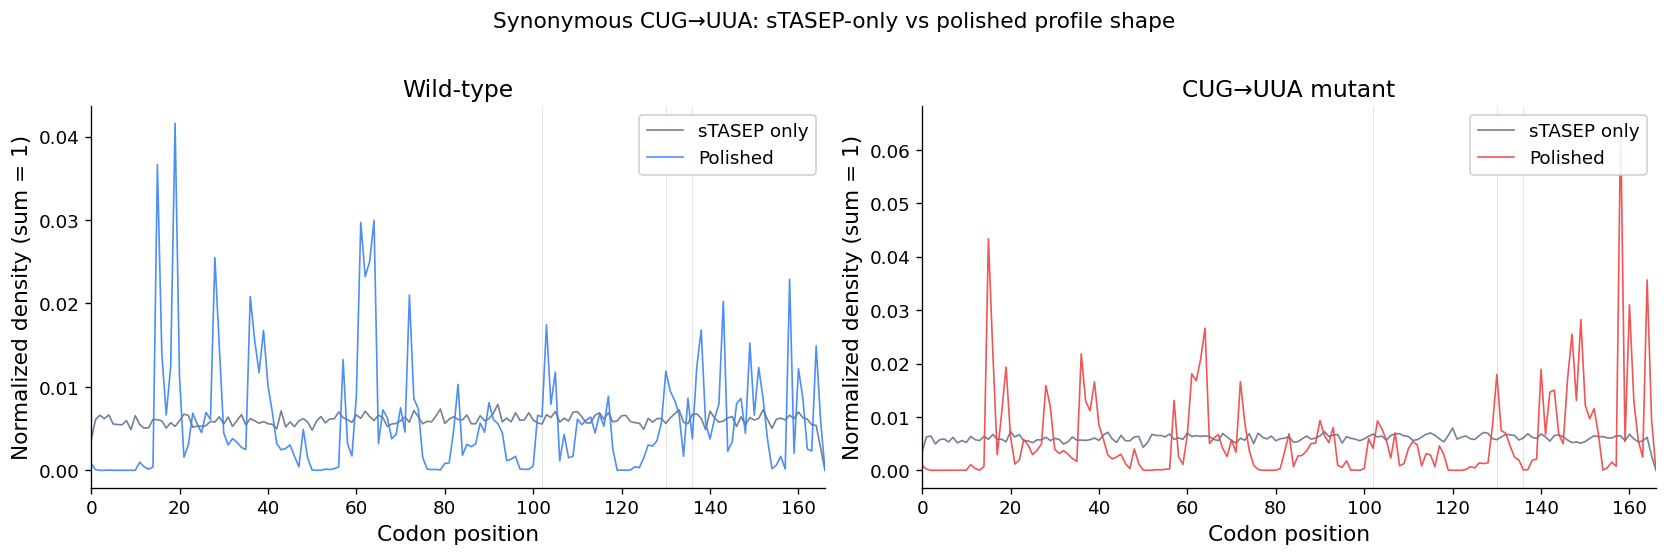

In [25]:
# Overlay sTASEP-only vs polished (requires predictions from the cells above)
def _unit_area(y):
    y = np.asarray(y, dtype=float)
    return y / (y.sum() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

for ax, raw, pol, title, pol_color in (
    (axes[0], wt_raw, wt_profile, "Wild-type", "#3b82f6"),
    (axes[1], mut_raw, mut_profile, "CUG→UUA mutant", "#ef4444"),
):
    xv = np.arange(len(raw))
    ax.plot(xv, _unit_area(raw), color="#64748b", linewidth=1.0, label="sTASEP only", alpha=0.9)
    ax.plot(xv, _unit_area(pol), color=pol_color, linewidth=1.0, label="Polished", alpha=0.9)
    for pos in mut_positions:
        ax.axvline(pos, color="#d4d4d4", linewidth=0.35, zorder=0)
    ax.set_title(title)
    ax.set_xlabel("Codon position")
    ax.set_ylabel("Normalized density (sum = 1)")
    ax.set_xlim(0, len(xv) - 1)
    ax.legend(loc="upper right", framealpha=0.9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Synonymous CUG→UUA: sTASEP-only vs polished profile shape", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


---
## 10. sTASEP Parameter Sensitivity

The sTASEP simulation has two key user-controllable parameters:

- **`init_p`** — ribosome initiation probability. Higher values mean more ribosomes attempt to load onto the transcript per time step.
- **`n_stasep_runs`** — number of independent simulation replicas averaged together. More runs reduce stochastic noise.

Understanding how these parameters affect the output helps calibrate predictions and assess confidence.


Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.001)...
Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.005)...
Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.02)...
Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.05)...


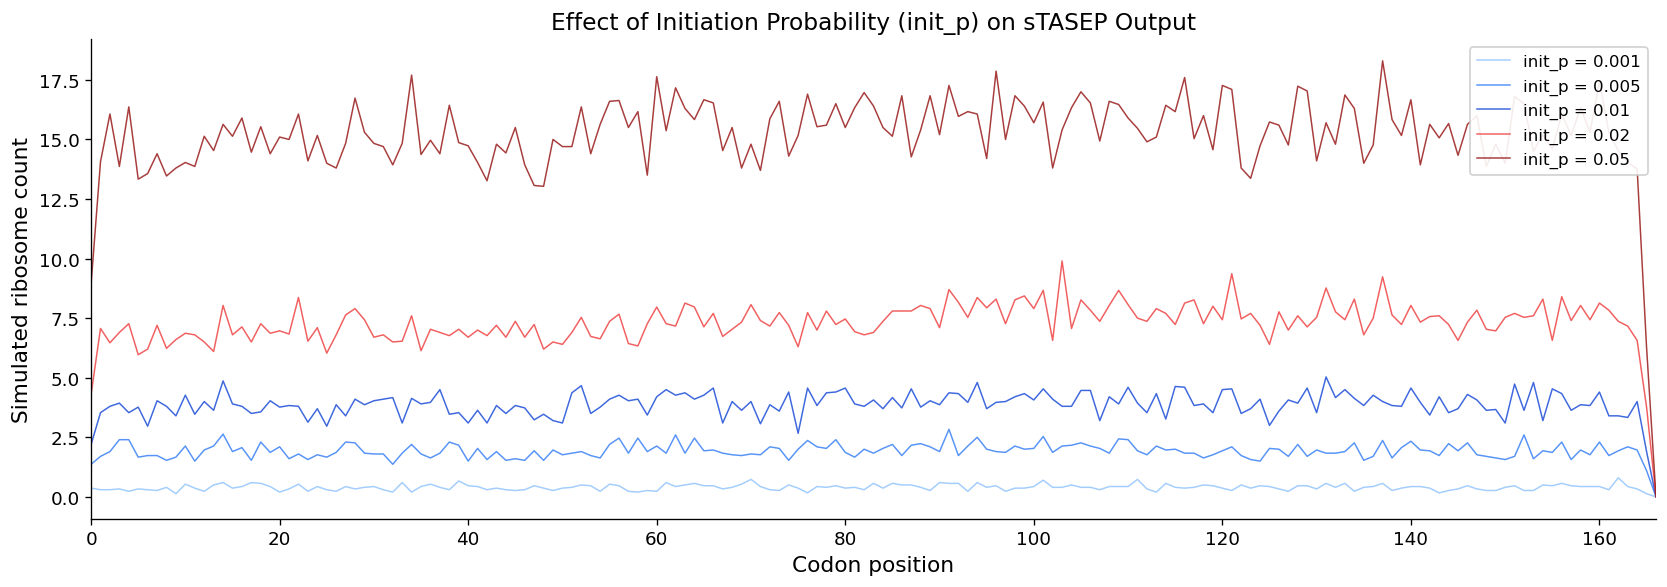

In [26]:
# Effect of init_p on simulation output (sTASEP only, no polisher)
# Always use demo CDS + matching x-axis (FASTA cells overwrite `seq`).
plot_seq = demo_cds_seq
x_plot = np.arange(demo_n_codons)
init_p_values = [0.001, 0.005, 0.01, 0.02, 0.05]
init_p_colors = ["#93c5fd", "#3b82f6", "#1d4ed8", "#ef4444", "#991b1b"]

fig, ax = plt.subplots(figsize=(14, 5))
for ip, color in zip(init_p_values, init_p_colors):
    pred = predictor_ipsc.predict(
        plot_seq, task="riboseq", use_polisher=False, n_stasep_runs=30, init_p=ip
    )[0]
    ax.plot(x_plot, pred, color=color, linewidth=0.9, label=f"init_p = {ip}", alpha=0.85)

ax.set_xlabel("Codon position")
ax.set_ylabel("Simulated ribosome count")
ax.set_title("Effect of Initiation Probability (init_p) on sTASEP Output")
ax.legend(loc="upper right", framealpha=0.9, fontsize=10)
ax.set_xlim(0, demo_n_codons - 1)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Running sTASEP simulation for 1 sequences with 1 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 5 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 10 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 200 runs per sequence (init_p=0.01)...


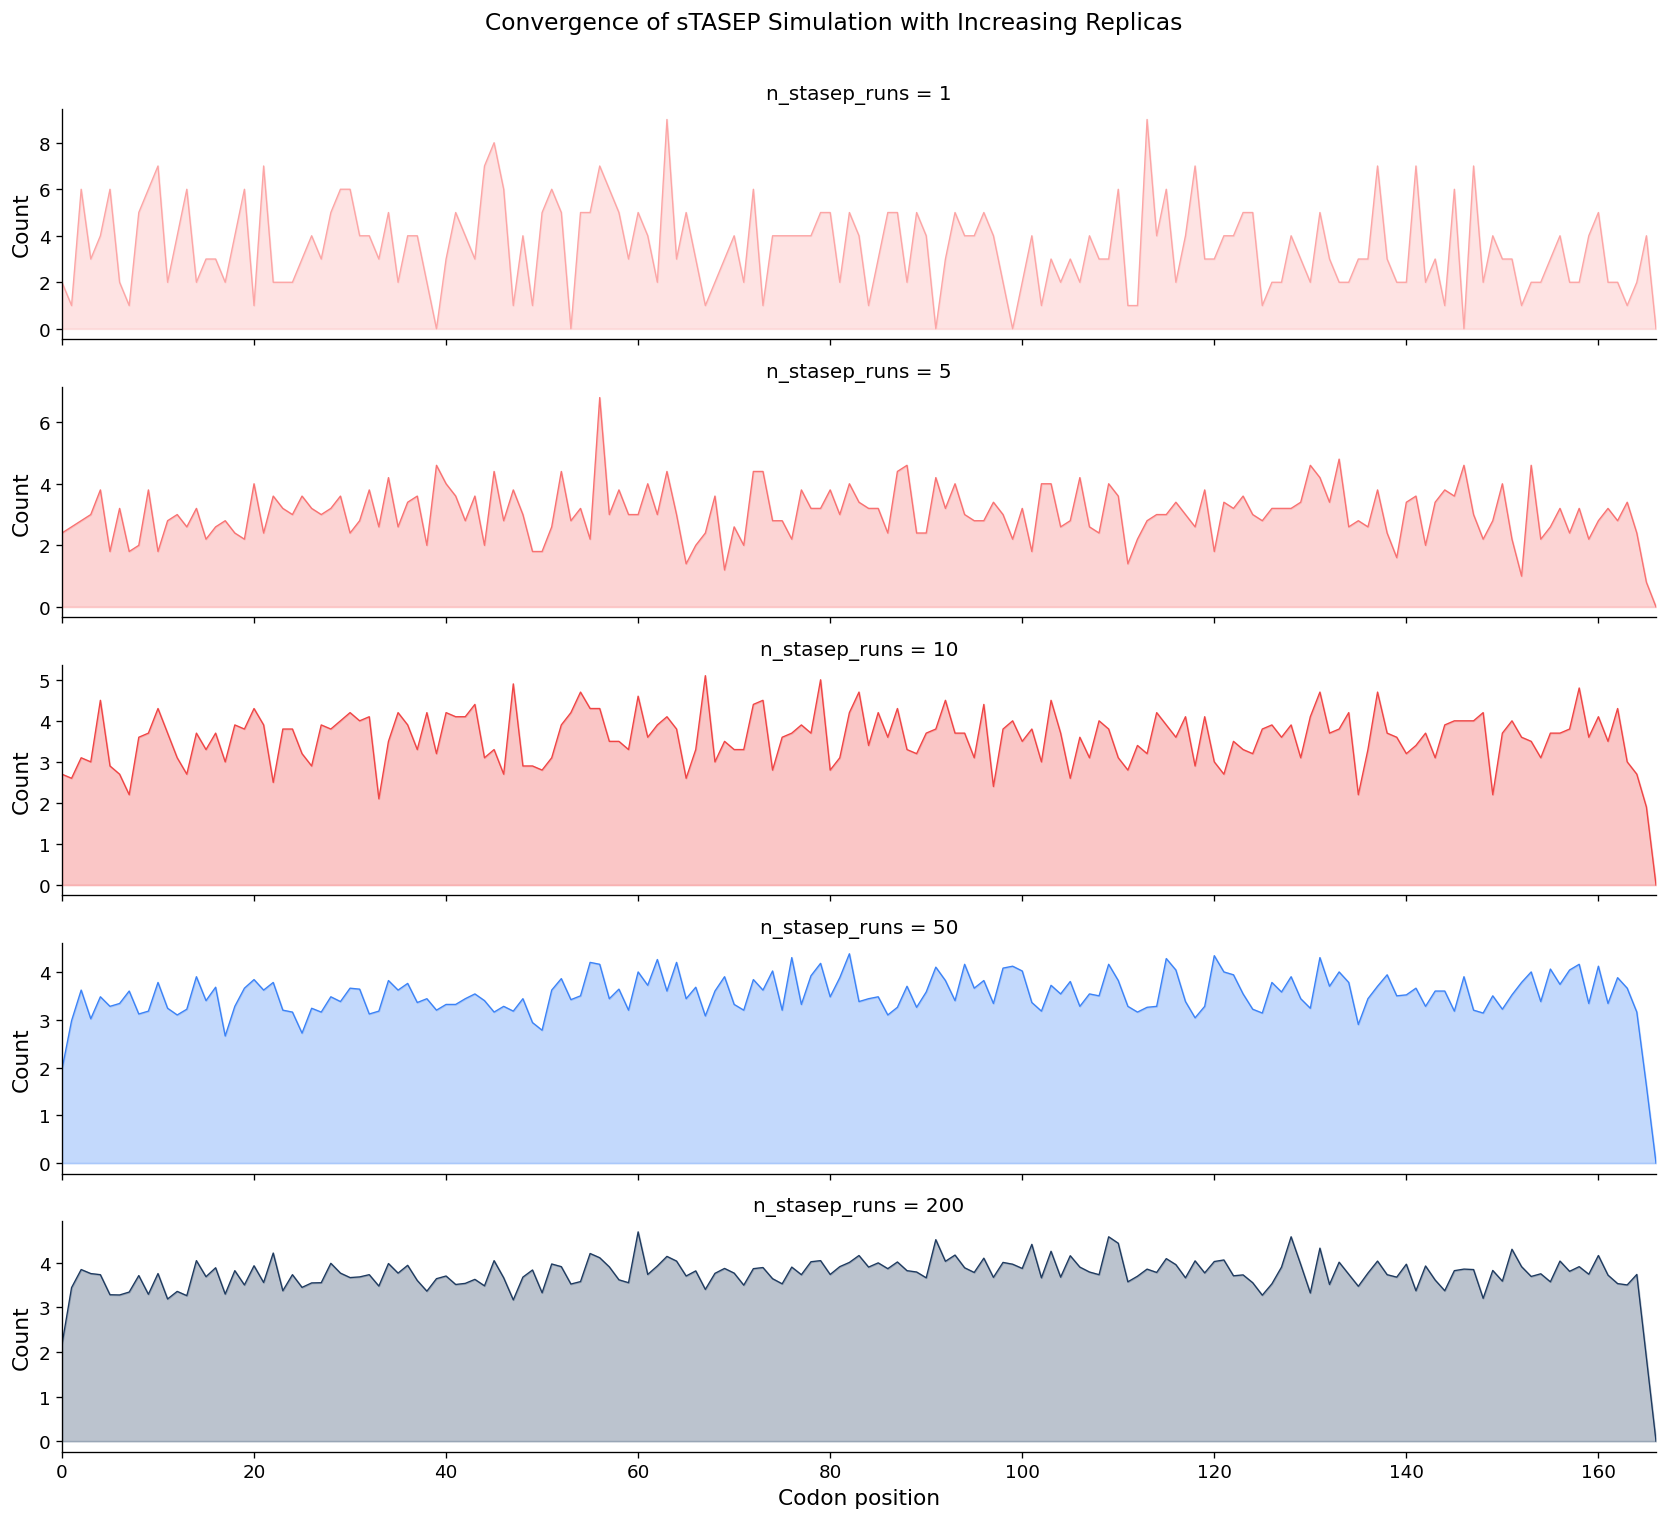

More replicas → smoother profile. The default (50–100) is a good balance.


In [27]:
# Effect of n_stasep_runs on simulation noise
plot_seq = demo_cds_seq
x_plot = np.arange(demo_n_codons)
n_runs_values = [1, 5, 10, 50, 200]
run_colors = ["#fca5a5", "#f87171", "#ef4444", "#3b82f6", "#1e3a5f"]

fig, axes = plt.subplots(len(n_runs_values), 1, figsize=(14, 2.5 * len(n_runs_values)),
                          sharex=True, sharey=False)

for ax, n_runs, color in zip(axes, n_runs_values, run_colors):
    pred = predictor_ipsc.predict(
        plot_seq, task="riboseq", use_polisher=False, n_stasep_runs=n_runs
    )[0]
    ax.fill_between(x_plot, pred, alpha=0.3, color=color)
    ax.plot(x_plot, pred, color=color, linewidth=0.8)
    ax.set_ylabel("Count")
    ax.set_title(f"n_stasep_runs = {n_runs}", fontsize=12)
    ax.set_xlim(0, demo_n_codons - 1)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Codon position")
fig.suptitle("Convergence of sTASEP Simulation with Increasing Replicas",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()
print("More replicas → smoother profile. The default (50–100) is a good balance.")

---

## Summary

| Task | Input | Output | Use case |
|------|-------|--------|----------|
| `riboseq` | CDS sequence | Per-codon ribosome counts | Identify ribosome pause sites, stalling |
| `te` | CDS (or CDS + UTRs) | Translation efficiency scalar | Compare translational output across variants |
| `protein` | CDS sequence | Protein expression scalar | Predict relative protein levels |

For more details, see the [paper](https://www.biorxiv.org/content/10.64898/2026.02.08.700508v2) and [README](../README.md).